<a href="https://colab.research.google.com/github/ridhoakfa/Bike-Sharing-Dashboard/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Ridho Akbar Fadhilah
- **Email:** CDCC200D6Y1029@student.devacademy.id
- **ID Dicoding:** CDCC200D6Y1029

## Menentukan Pertanyaan Bisnis

- Sejauh mana hubungan antara faktor lingkungan seperti suhu, kelembapan, dan kecepatan angin terhadap jumlah penyewaan sepeda?
- Bagaimana variasi kondisi cuaca memengaruhi pola penggunaan layanan penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [37]:
import kagglehub
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

In [38]:
# Download Dataset dari Kaggle
dataset_path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Dataset berhasil diunduh di:", dataset_path)

# Cek isi folder dataset
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

# Load Dataset
hour_df = pd.read_csv(os.path.join(dataset_path, "hour.csv"))
day_df = pd.read_csv(os.path.join(dataset_path, "day.csv"))

# Simpan Raw Data
raw_hour_df = hour_df.copy()
raw_day_df = day_df.copy()

# Preview data hour
hour_df.head()

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Dataset berhasil diunduh di: /kaggle/input/bike-sharing-dataset
/kaggle/input/bike-sharing-dataset/hour.csv
/kaggle/input/bike-sharing-dataset/Readme.txt
/kaggle/input/bike-sharing-dataset/day.csv


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [39]:
# Preview data day
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset terdiri dari dua jenis data utama, yaitu data penyewaan sepeda berbasis waktu per jam (`hour.csv`) dan per hari (`day.csv`).
- Informasi yang tersedia mencakup berbagai faktor seperti kondisi musim dan cuaca, di mana variabel `season` dan `weathersit` merepresentasikan kategori lingkungan, serta `temp` (suhu), `hum` (kelembapan), dan `windspeed` (kecepatan angin).
- Selain itu, dataset juga memuat informasi waktu seperti `year`, `month`, `hr`, `weekday`, serta kategori pengguna yaitu `casual` dan `registered`, yang memungkinkan analisis perilaku pengguna secara lebih mendalam.

### Assessing Data

In [40]:
# Menampilkan jumlah baris dan kolom pada masing-masing dataset

print("Informasi dataset hour.csv:")
print("Jumlah baris:", hour_df.shape[0])
print("Jumlah kolom:", hour_df.shape[1])

print("\nInformasi dataset day.csv:")
print("Jumlah baris:", day_df.shape[0])
print("Jumlah kolom:", day_df.shape[1])

Informasi dataset hour.csv:
Jumlah baris: 17379
Jumlah kolom: 17

Informasi dataset day.csv:
Jumlah baris: 731
Jumlah kolom: 16


In [41]:
print("Tipe data pada hour.csv:")
hour_df.info()

print("\nTipe data pada day.csv:")
day_df.info()

Tipe data pada hour.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Tipe data pada day.csv:

In [42]:
# Mengecek jumlah missing values pada dataset hour

missing_hour = hour_df.isna().sum()
print("Missing values pada hour.csv:")
display(missing_hour.to_frame(name="Jumlah Missing"))

Missing values pada hour.csv:


,Jumlah Missing
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [43]:
# Mengecek jumlah missing values pada dataset day

missing_day = day_df.isna().sum()
print("Missing values pada day.csv:")
display(missing_day.to_frame(name="Jumlah Missing"))

Missing values pada day.csv:


,Jumlah Missing
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [44]:
# Mengecek jumlah data duplikat

print("Jumlah data duplikat pada hour.csv:", hour_df.duplicated().sum())
print("Jumlah data duplikat pada day.csv:", day_df.duplicated().sum())

Jumlah data duplikat pada hour.csv: 0
Jumlah data duplikat pada day.csv: 0


In [45]:
# Mengidentifikasi outlier pada day.csv menggunakan metode IQR

Q1_day = day_df["cnt"].quantile(0.25)
Q3_day = day_df["cnt"].quantile(0.75)
IQR_day = Q3_day - Q1_day

lower_day = Q1_day - 1.5 * IQR_day
upper_day = Q3_day + 1.5 * IQR_day

outlier_day = day_df[(day_df["cnt"] < lower_day) | (day_df["cnt"] > upper_day)]

print("Jumlah outlier pada day.csv:", outlier_day.shape[0])
outlier_day.head()

Jumlah outlier pada day.csv: 0


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


In [46]:
# Mengidentifikasi outlier pada hour.csv menggunakan metode IQR

Q1_hour = hour_df["cnt"].quantile(0.25)
Q3_hour = hour_df["cnt"].quantile(0.75)
IQR_hour = Q3_hour - Q1_hour

lower_hour = Q1_hour - 1.5 * IQR_hour
upper_hour = Q3_hour + 1.5 * IQR_hour

outlier_hour = hour_df[(hour_df["cnt"] < lower_hour) | (hour_df["cnt"] > upper_hour)]

print("Jumlah outlier pada hour.csv:", outlier_hour.shape[0])
outlier_hour.head()

Jumlah outlier pada hour.csv: 505


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
5536,5537,2011-08-23,3,0,8,14,0,2,1,1,0.72,0.6515,0.30,0.0896,149,502,651
10358,10359,2012-03-12,1,1,3,17,0,1,1,2,0.62,0.6212,0.38,0.4179,87,557,644
10359,10360,2012-03-12,1,1,3,18,0,1,1,2,0.60,0.6212,0.43,0.1940,89,623,712
10382,10383,2012-03-13,1,1,3,17,0,2,1,1,0.70,0.6364,0.37,0.1045,62,614,676
10383,10384,2012-03-13,1,1,3,18,0,2,1,1,0.70,0.6364,0.34,0.2985,96,638,734


**Insight:**

- **Informasi Dataset:**
  - Dataset `hour.csv` memiliki sebanyak **17.379 baris** dan **17 kolom** yang merepresentasikan data penyewaan sepeda dalam skala waktu per jam selama dua tahun.
  - Dataset `day.csv` memiliki sebanyak **731 baris** dan **16 kolom** yang merepresentasikan data penyewaan sepeda dalam skala harian.
  - Struktur kedua dataset relatif serupa, dengan perbedaan utama pada keberadaan variabel `hr` (jam) pada `hour.csv`.

- **Tipe Data:**
  - Sebagian besar variabel sudah memiliki tipe data yang sesuai (numerik), namun kolom `dteday` masih bertipe object sehingga perlu dikonversi menjadi datetime untuk analisis lebih lanjut.

- **Missing Values:**
  - Tidak ditemukan nilai yang hilang pada kedua dataset, sehingga tidak diperlukan penanganan missing values.

- **Duplikasi Data:**
  - Tidak terdapat data duplikat, sehingga seluruh data dapat digunakan tanpa perlu proses deduplikasi.

- **Outlier:**
  - Pada dataset `day.csv`, tidak ditemukan outlier pada variabel `cnt`, yang menunjukkan bahwa pola penyewaan harian cenderung stabil.
  - Pada dataset `hour.csv`, terdapat sejumlah outlier yang mengindikasikan adanya lonjakan atau penurunan jumlah penyewaan pada jam-jam tertentu.
  - Outlier tersebut kemungkinan berkaitan dengan jam sibuk (rush hour) atau kondisi tertentu seperti cuaca ekstrem.

### Cleaning Data

In [47]:
# Menghapus outlier pada dataset hour.csv berdasarkan batas IQR

print("Jumlah data sebelum menghapus outlier:", hour_df.shape)

hour_df = hour_df[(hour_df["cnt"] >= lower_hour) & (hour_df["cnt"] <= upper_hour)]

print("Jumlah data setelah menghapus outlier:", hour_df.shape)

Jumlah data sebelum menghapus outlier: (17379, 17)
Jumlah data setelah menghapus outlier: (16874, 17)


In [48]:
# Mengubah tipe data kolom dteday menjadi datetime
# Hal ini penting agar analisis berbasis waktu bisa dilakukan dengan lebih akurat

hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

In [49]:
# Menambahkan fitur berbasis waktu

# Dataset hourly
hour_df["year"] = hour_df["dteday"].dt.year
hour_df["month"] = hour_df["dteday"].dt.month
hour_df["day"] = hour_df["dteday"].dt.day
hour_df["day_of_week"] = hour_df["dteday"].dt.day_name()
hour_df["hour_of_day"] = hour_df["hr"]

# Dataset daily
day_df["year"] = day_df["dteday"].dt.year
day_df["month"] = day_df["dteday"].dt.month
day_df["day"] = day_df["dteday"].dt.day
day_df["day_of_week"] = day_df["dteday"].dt.day_name()

In [50]:
# Mengubah kode kategori menjadi label yang lebih mudah dipahami

# Mapping musim
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

# Mapping kondisi cuaca
weather_map = {
    1: "Cerah",
    2: "Berawan",
    3: "Hujan Ringan",
    4: "Hujan Lebat"
}

hour_df["season_name"] = hour_df["season"].map(season_map)
hour_df["weather_condition"] = hour_df["weathersit"].map(weather_map)

day_df["season_name"] = day_df["season"].map(season_map)
day_df["weather_condition"] = day_df["weathersit"].map(weather_map)

In [51]:
# Menghitung persentase pengguna casual dan registered

hour_df["casual_pct"] = hour_df["casual"] / hour_df["cnt"] * 100
hour_df["registered_pct"] = hour_df["registered"] / hour_df["cnt"] * 100

day_df["casual_pct"] = day_df["casual"] / day_df["cnt"] * 100
day_df["registered_pct"] = day_df["registered"] / day_df["cnt"] * 100

In [52]:
# Menampilkan ringkasan dataset setelah proses cleaning

print("Proses data cleaning selesai")

print("\nUkuran dataset hour.csv:", hour_df.shape)
print("Ukuran dataset day.csv:", day_df.shape)

print("\nInformasi hour.csv:")
hour_df.info()

print("\nInformasi day.csv:")
day_df.info()

# Preview dataset hourly
hour_df.head()

Proses data cleaning selesai

Ukuran dataset hour.csv: (16874, 26)
Ukuran dataset day.csv: (731, 24)

Informasi hour.csv:
<class 'pandas.core.frame.DataFrame'>
Index: 16874 entries, 0 to 17378
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            16874 non-null  int64         
 1   dteday             16874 non-null  datetime64[ns]
 2   season             16874 non-null  int64         
 3   yr                 16874 non-null  int64         
 4   mnth               16874 non-null  int64         
 5   hr                 16874 non-null  int64         
 6   holiday            16874 non-null  int64         
 7   weekday            16874 non-null  int64         
 8   workingday         16874 non-null  int64         
 9   weathersit         16874 non-null  int64         
 10  temp               16874 non-null  float64       
 11  atemp              16874 non-null  float64       
 12 

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,cnt,year,month,day,day_of_week,hour_of_day,season_name,weather_condition,casual_pct,registered_pct
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,16,2011,1,1,Saturday,0,Spring,Cerah,18.750000,81.250000
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,40,2011,1,1,Saturday,1,Spring,Cerah,20.000000,80.000000
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,32,2011,1,1,Saturday,2,Spring,Cerah,15.625000,84.375000
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,13,2011,1,1,Saturday,3,Spring,Cerah,23.076923,76.923077
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,1,2011,1,1,Saturday,4,Spring,Cerah,0.000000,100.000000


In [53]:
# Preview dataset daily

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,registered,cnt,year,month,day,day_of_week,season_name,weather_condition,casual_pct,registered_pct
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,654,985,2011,1,1,Saturday,Spring,Berawan,33.604061,66.395939
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,670,801,2011,1,2,Sunday,Spring,Berawan,16.354557,83.645443
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,1229,1349,2011,1,3,Monday,Spring,Cerah,8.895478,91.104522
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,1454,1562,2011,1,4,Tuesday,Spring,Cerah,6.914213,93.085787
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,1518,1600,2011,1,5,Wednesday,Spring,Cerah,5.125000,94.875000


**Insight:**

- **Penanganan Outlier:**
  - Outlier pada variabel `cnt` di dataset `hour.csv` telah dihapus menggunakan metode IQR untuk mengurangi pengaruh nilai ekstrem terhadap analisis.
  - Penghapusan ini menyebabkan jumlah data berkurang, namun meningkatkan kualitas dan kestabilan pola data.

- **Perubahan Tipe Data:**
  - Kolom `dteday` pada kedua dataset berhasil dikonversi menjadi tipe datetime sehingga memungkinkan analisis berbasis waktu secara lebih akurat.

- **Feature Engineering:**
  - Ditambahkan beberapa variabel baru seperti `year`, `month`, `day`, dan `day_of_week` untuk memperkaya analisis temporal.
  - Variabel `hour_of_day` pada `hour.csv` memberikan detail tambahan terkait pola penggunaan dalam satu hari.

- **Transformasi Kategori:**
  - Variabel kategorikal seperti `season` dan `weathersit` diubah menjadi label yang lebih deskriptif melalui `season_name` dan `weather_condition`.
  - Transformasi ini membantu meningkatkan keterbacaan dan interpretasi hasil analisis.

- **Proporsi Pengguna:**
  - Perhitungan persentase `casual` dan `registered` memberikan gambaran kontribusi masing-masing tipe pengguna terhadap total penyewaan.

- **Kondisi Dataset Setelah Cleaning:**
  - Dataset menjadi lebih bersih, terstruktur, dan siap digunakan untuk analisis eksploratif maupun visualisasi lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore Data Numerik dan Kategorikal

In [54]:
# Statistik deskriptif untuk data numerik (hour)
print("Statistik Deskriptif Data Hour:")
hour_df.describe().T

Statistik Deskriptif Data Hour:


,count,mean,min,25%,50%,75%,max,std
instant,16874.0,8542.168899,1.0,4219.25,8438.5,12832.75,17379.0,5007.76604
dteday,16874,2011-12-26 23:54:06.699063808,2011-01-01 00:00:00,2011-06-29 00:00:00,2011-12-23 00:00:00,2012-06-23 00:00:00,2012-12-31 00:00:00,NaN
season,16874.0,2.490399,1.0,1.0,2.0,3.0,4.0,1.111966
yr,16874.0,0.487733,0.0,0.0,0.0,1.0,1.0,0.499864
mnth,16874.0,6.513275,1.0,4.0,7.0,10.0,12.0,3.462438
hr,16874.0,11.458101,0.0,5.0,11.0,18.0,23.0,6.962144
holiday,16874.0,0.029513,0.0,0.0,0.0,0.0,1.0,0.169244
weekday,16874.0,2.997748,0.0,1.0,3.0,5.0,6.0,2.013054
workingday,16874.0,0.678618,0.0,0.0,1.0,1.0,1.0,0.467021
weathersit,16874.0,1.430663,1.0,1.0,1.0,2.0,4.0,0.642689


In [55]:
# Statistik deskriptif untuk data numerik (day)
print("Statistik Deskriptif Data Day:")
day_df.describe().T

Statistik Deskriptif Data Day:


,count,mean,min,25%,50%,75%,max,std
instant,731.0,366.0,1.0,183.5,366.0,548.5,731.0,211.165812
dteday,731,2012-01-01 00:00:00,2011-01-01 00:00:00,2011-07-02 12:00:00,2012-01-01 00:00:00,2012-07-01 12:00:00,2012-12-31 00:00:00,NaN
season,731.0,2.49658,1.0,2.0,3.0,3.0,4.0,1.110807
yr,731.0,0.500684,0.0,0.0,1.0,1.0,1.0,0.500342
mnth,731.0,6.519836,1.0,4.0,7.0,10.0,12.0,3.451913
holiday,731.0,0.028728,0.0,0.0,0.0,0.0,1.0,0.167155
weekday,731.0,2.997264,0.0,1.0,3.0,5.0,6.0,2.004787
workingday,731.0,0.683995,0.0,0.0,1.0,1.0,1.0,0.465233
weathersit,731.0,1.395349,1.0,1.0,1.0,2.0,3.0,0.544894
temp,731.0,0.495385,0.05913,0.337083,0.498333,0.655417,0.861667,0.183051


In [56]:
# Distribusi kategori pada hour_df
print("Distribusi Musim (hour):")
print(hour_df['season_name'].value_counts())

print("\nDistribusi Kondisi Cuaca (hour):")
print(hour_df['weather_condition'].value_counts())

print("\nDistribusi Working Day (hour):")
print(hour_df['workingday'].value_counts())

print("\nDistribusi Holiday (hour):")
print(hour_df['holiday'].value_counts())

Distribusi Musim (hour):
season_name
Fall      4298
Summer    4253
Spring    4223
Winter    4100
Name: count, dtype: int64

Distribusi Kondisi Cuaca (hour):
weather_condition
Cerah           11020
Berawan          4444
Hujan Ringan     1407
Hujan Lebat         3
Name: count, dtype: int64

Distribusi Working Day (hour):
workingday
1    11451
0     5423
Name: count, dtype: int64

Distribusi Holiday (hour):
holiday
0    16376
1      498
Name: count, dtype: int64


In [57]:
# Distribusi kategori pada day_df
print("Distribusi Musim (day):")
print(day_df['season_name'].value_counts())

print("\nDistribusi Kondisi Cuaca (day):")
print(day_df['weather_condition'].value_counts())

print("\nDistribusi Working Day (day):")
print(day_df['workingday'].value_counts())

print("\nDistribusi Holiday (day):")
print(day_df['holiday'].value_counts())

Distribusi Musim (day):
season_name
Fall      188
Summer    184
Spring    181
Winter    178
Name: count, dtype: int64

Distribusi Kondisi Cuaca (day):
weather_condition
Cerah           463
Berawan         247
Hujan Ringan     21
Name: count, dtype: int64

Distribusi Working Day (day):
workingday
1    500
0    231
Name: count, dtype: int64

Distribusi Holiday (day):
holiday
0    710
1     21
Name: count, dtype: int64


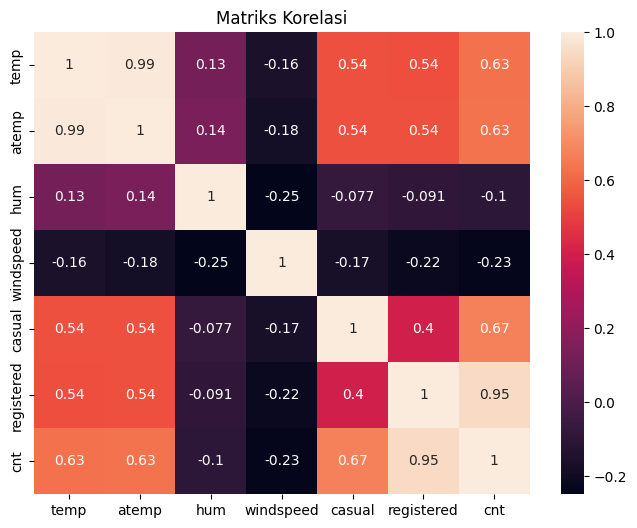


Matriks Korelasi:
                temp     atemp       hum  windspeed    casual  registered  \
temp        1.000000  0.991702  0.126963  -0.157944  0.543285    0.540012   
atemp       0.991702  1.000000  0.139988  -0.183643  0.543864    0.544192   
hum         0.126963  0.139988  1.000000  -0.248489 -0.077008   -0.091089   
windspeed  -0.157944 -0.183643 -0.248489   1.000000 -0.167613   -0.217449   
casual      0.543285  0.543864 -0.077008  -0.167613  1.000000    0.395282   
registered  0.540012  0.544192 -0.091089  -0.217449  0.395282    1.000000   
cnt         0.627494  0.631066 -0.100659  -0.234545  0.672804    0.945517   

                 cnt  
temp        0.627494  
atemp       0.631066  
hum        -0.100659  
windspeed  -0.234545  
casual      0.672804  
registered  0.945517  
cnt         1.000000  


In [58]:
# Korelasi antar variabel numerik
corr_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Matriks Korelasi")
plt.show()

print("\nMatriks Korelasi:")
print(corr_matrix)

**Insight:**

* **Statistik Deskriptif:**

  * Pada data per jam (`hour_df`), rata-rata jumlah penyewaan sepeda sekitar 172 unit per jam, dengan nilai maksimum mencapai lebih dari 600, menunjukkan adanya lonjakan penggunaan pada waktu-waktu tertentu.
  * Pada data harian (`day_df`), rata-rata penyewaan mencapai sekitar 4.500 sepeda per hari, dengan variasi yang cukup besar antara hari dengan permintaan rendah dan tinggi.
  * Pengguna terdaftar (registered) secara konsisten jauh lebih banyak dibandingkan pengguna kasual, baik pada data per jam maupun per hari, yang menunjukkan dominasi pengguna tetap dalam sistem.
  * Variabel suhu berada di sekitar nilai tengah (±0.49), menandakan kondisi cuaca yang cukup bervariasi sepanjang periode observasi.

* **Distribusi Data Kategorikal:**

  * Distribusi musim relatif merata pada kedua dataset, sehingga analisis perbandingan antar musim dapat dilakukan secara adil tanpa ketimpangan jumlah data.
  * Kondisi cuaca didominasi oleh cuaca cerah, diikuti oleh kondisi berawan, sementara hujan ringan dan hujan lebat memiliki proporsi yang jauh lebih kecil.
  * Sebagian besar observasi terjadi pada hari kerja (working day), yang mengindikasikan bahwa aktivitas penyewaan sepeda banyak dipengaruhi oleh kebutuhan rutin.
  * Hari libur memiliki jumlah yang sangat sedikit dibandingkan hari biasa, sehingga pola pada hari libur perlu dianalisis secara khusus.

* **Analisis Korelasi:**

  * Suhu (`temp` dan `atemp`) memiliki hubungan positif yang cukup kuat dengan jumlah penyewaan sepeda (`cnt`), yang berarti semakin tinggi suhu, semakin meningkat jumlah penyewaan.
  * Kelembapan (`hum`) menunjukkan korelasi negatif yang lemah terhadap jumlah penyewaan, sehingga pengaruhnya tidak terlalu signifikan.
  * Kecepatan angin (`windspeed`) memiliki hubungan negatif yang lebih terlihat dibandingkan kelembapan, yang mengindikasikan bahwa angin kencang dapat menurunkan minat bersepeda.
  * Jumlah pengguna terdaftar (`registered`) memiliki korelasi yang sangat tinggi dengan total penyewaan, menandakan bahwa kontribusi utama berasal dari pengguna tetap.
  * Pengguna kasual (`casual`) juga memiliki korelasi positif, namun tidak sekuat pengguna terdaftar.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Sejauh mana hubungan antara faktor lingkungan seperti suhu, kelembapan, dan kecepatan angin terhadap jumlah penyewaan sepeda?

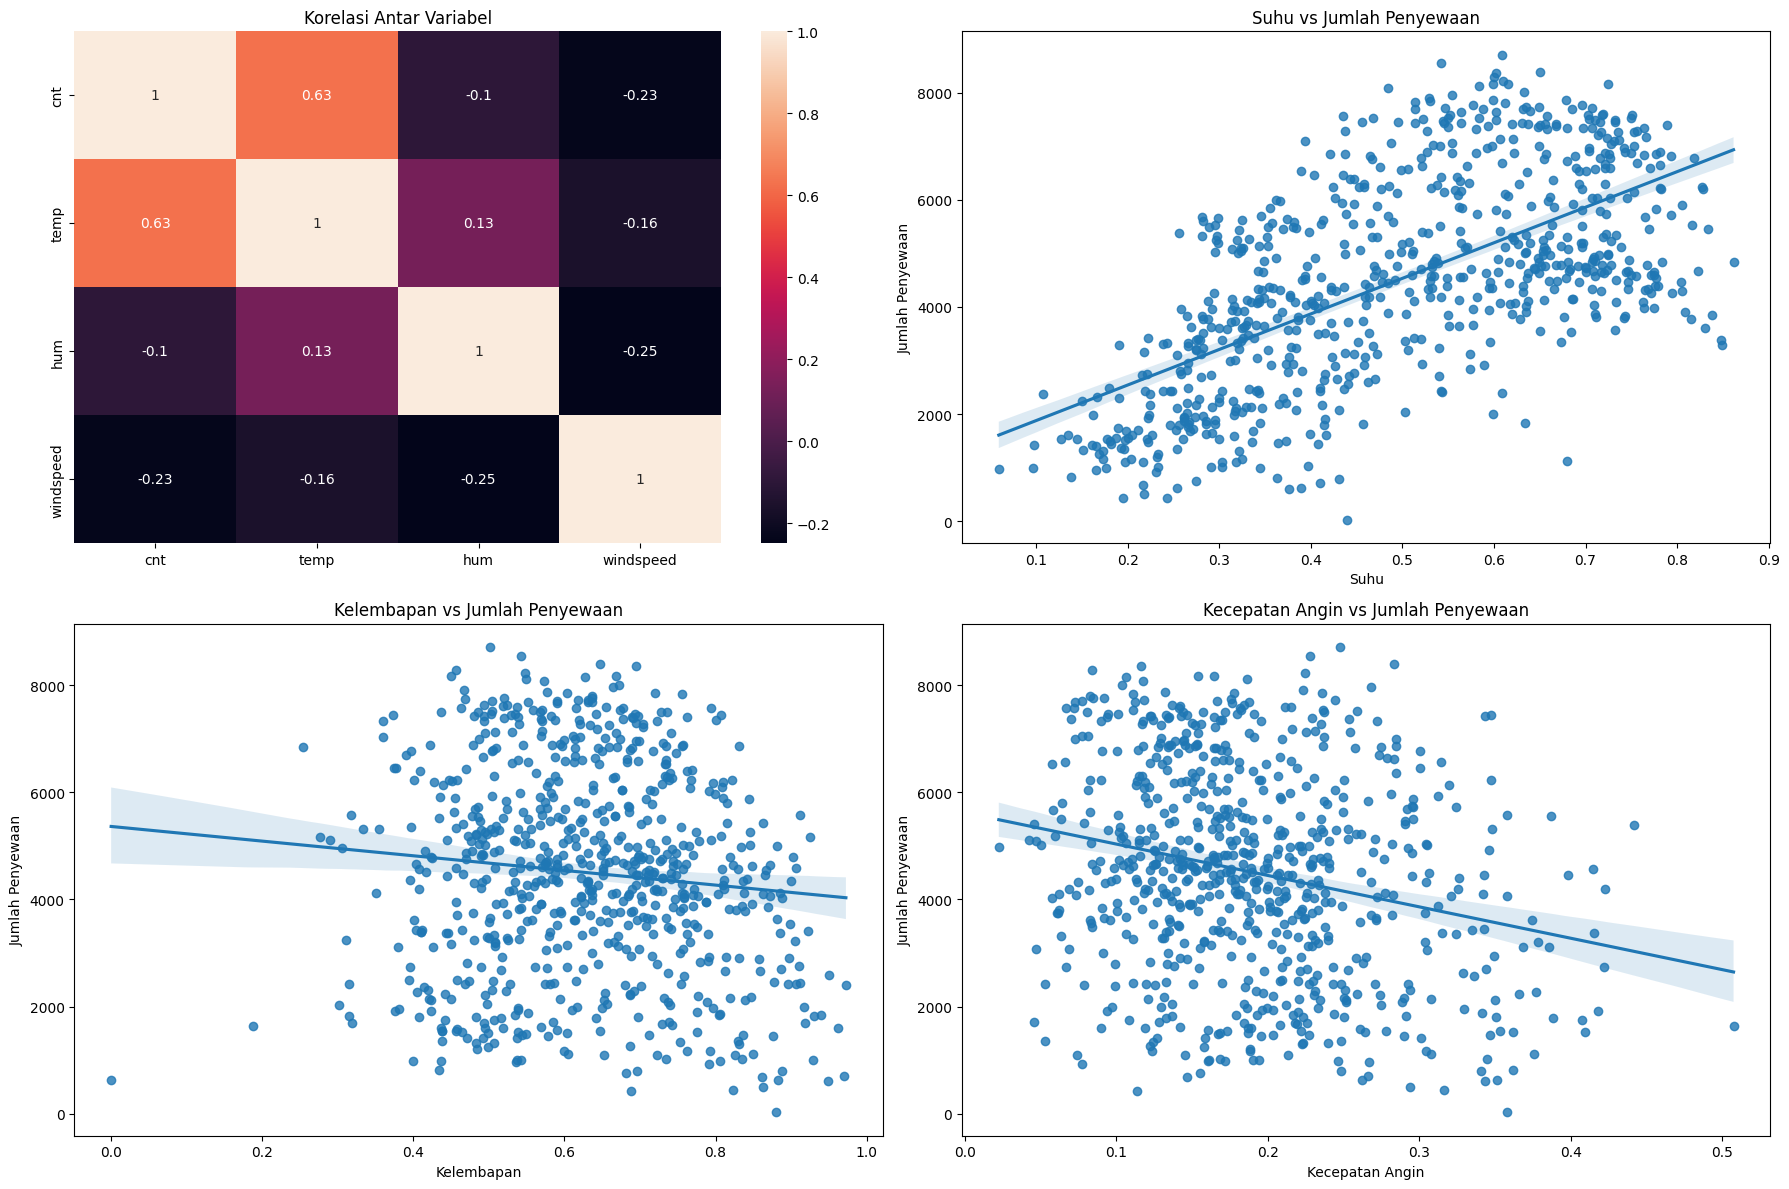

In [59]:
# Visualisasi hubungan faktor lingkungan dengan jumlah penyewaan sepeda

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Heatmap (overview)
corr_matrix = day_df[["cnt", "temp", "hum", "windspeed"]].corr()
sns.heatmap(corr_matrix, annot=True, ax=axes[0, 0])
axes[0, 0].set_title("Korelasi Antar Variabel")

# Suhu vs Penyewaan
sns.regplot(x="temp", y="cnt", data=day_df, ax=axes[0, 1])
axes[0, 1].set_title("Suhu vs Jumlah Penyewaan")
axes[0, 1].set_xlabel("Suhu")
axes[0, 1].set_ylabel("Jumlah Penyewaan")

# Kelembapan
sns.regplot(x="hum", y="cnt", data=day_df, ax=axes[1, 0])
axes[1, 0].set_title("Kelembapan vs Jumlah Penyewaan")
axes[1, 0].set_xlabel("Kelembapan")
axes[1, 0].set_ylabel("Jumlah Penyewaan")

# Windspeed
sns.regplot(x="windspeed", y="cnt", data=day_df, ax=axes[1, 1])
axes[1, 1].set_title("Kecepatan Angin vs Jumlah Penyewaan")
axes[1, 1].set_xlabel("Kecepatan Angin")
axes[1, 1].set_ylabel("Jumlah Penyewaan")

plt.tight_layout()
plt.show()

**Insight:**

* **Korelasi Antar Variabel (Heatmap - Kiri Atas):**

  * Variabel **suhu (temp)** memiliki korelasi positif yang cukup kuat (≈ 0,63) terhadap jumlah penyewaan sepeda (**cnt**), menunjukkan bahwa kenaikan suhu cenderung diikuti oleh peningkatan jumlah penyewaan.
  * **Kelembapan (hum)** memiliki korelasi negatif yang sangat lemah (≈ -0,10), sehingga pengaruhnya terhadap jumlah penyewaan relatif kecil.
  * **Kecepatan angin (windspeed)** menunjukkan korelasi negatif (≈ -0,23), yang berarti peningkatan kecepatan angin cenderung menurunkan jumlah penyewaan.
  * Secara keseluruhan, suhu menjadi faktor paling dominan, sementara kelembapan dan angin berperan sebagai faktor tambahan dengan pengaruh yang lebih kecil.

* **Hubungan Suhu dengan Jumlah Penyewaan (Scatter Plot - Kanan Atas):**

  * Scatter plot menunjukkan pola hubungan **linear positif** antara suhu dan jumlah penyewaan sepeda.
  * Garis regresi yang menanjak menegaskan bahwa semakin tinggi suhu, jumlah penyewaan cenderung meningkat.
  * Meskipun terdapat variasi data yang cukup besar, tren peningkatan tetap terlihat jelas.
  * Hal ini menunjukkan bahwa kondisi cuaca yang lebih hangat meningkatkan kenyamanan pengguna sehingga mendorong penggunaan sepeda.

* **Hubungan Kelembapan dengan Jumlah Penyewaan (Scatter Plot - Kiri Bawah):**

  * Pola hubungan antara kelembapan dan jumlah penyewaan menunjukkan kecenderungan **negatif**.
  * Garis regresi yang sedikit menurun mengindikasikan bahwa peningkatan kelembapan diikuti oleh penurunan jumlah penyewaan.
  * Namun, penyebaran data yang cukup luas menunjukkan bahwa kekuatan hubungan ini tergolong lemah.
  * Hal ini mengindikasikan bahwa kelembapan bukan faktor utama yang memengaruhi keputusan pengguna dalam menyewa sepeda.

* **Hubungan Kecepatan Angin dengan Jumlah Penyewaan (Scatter Plot - Kanan Bawah):**

  * Scatter plot memperlihatkan hubungan **negatif** antara kecepatan angin dan jumlah penyewaan sepeda.
  * Garis regresi yang menurun menunjukkan bahwa semakin tinggi kecepatan angin, jumlah penyewaan cenderung menurun.
  * Penyebaran data yang cukup luas menunjukkan bahwa kekuatan hubungan berada pada kategori lemah hingga sedang.
  * Hal ini menunjukkan bahwa kondisi berangin dapat mengurangi kenyamanan bersepeda dan berdampak pada penurunan minat pengguna.

### Pertanyaan 2: Bagaimana variasi kondisi cuaca memengaruhi pola penggunaan layanan penyewaan sepeda?

In [60]:
# Menghitung statistik penyewaan berdasarkan kondisi cuaca
weather_stats = day_df.groupby("weather_condition")["cnt"].agg(["mean", "sum"]).sort_values("sum", ascending=False)

weather_stats

,mean,sum
weather_condition,,
Cerah,4876.786177,2257952
Berawan,4035.862348,996858
Hujan Ringan,1803.285714,37869


/tmp/ipykernel_11215/3826196595.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_stats.index, y=weather_stats["sum"], palette="viridis", ax=axes[0, 0])
/tmp/ipykernel_11215/3826196595.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_stats.index, y=weather_stats["mean"], palette="viridis", ax=axes[0, 1])
/tmp/ipykernel_11215/3826196595.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x="weather_condition", y="cnt", data=day_df, estimator="sum", ci=None, marker="o", ax=axes[1, 1])


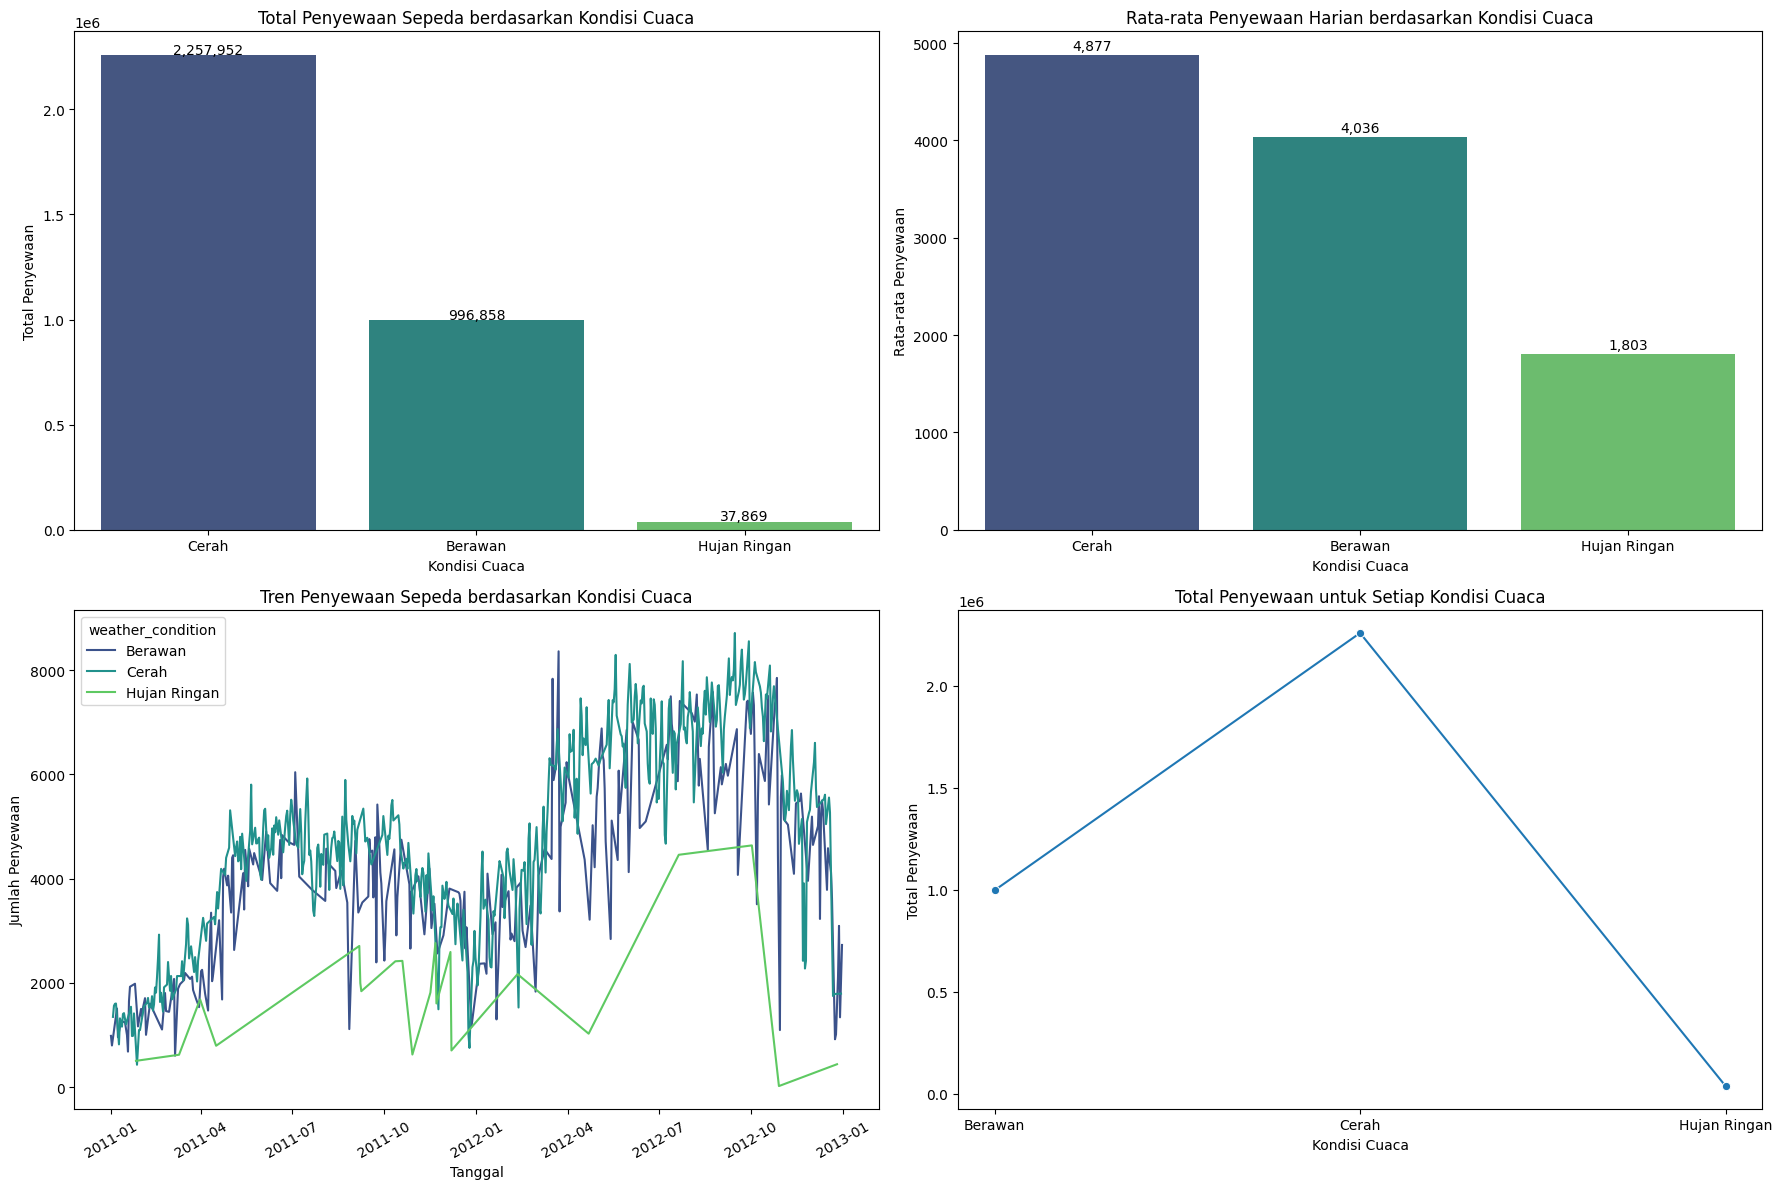

In [61]:
# Visualisasi pengaruh kondisi cuaca terhadap penyewaan sepeda

# Membuat layout subplot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Bar chart: total penyewaan sepeda berdasarkan kondisi cuaca
sns.barplot(x=weather_stats.index, y=weather_stats["sum"], palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Total Penyewaan Sepeda berdasarkan Kondisi Cuaca")
axes[0, 0].set_ylabel("Total Penyewaan")
axes[0, 0].set_xlabel("Kondisi Cuaca")

# Menambahkan label nilai
for i, v in enumerate(weather_stats["sum"]):
    axes[0, 0].text(i, v + 7000, f"{v:,.0f}", ha="center")

# Bar chart: rata-rata penyewaan harian
sns.barplot(x=weather_stats.index, y=weather_stats["mean"], palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Rata-rata Penyewaan Harian berdasarkan Kondisi Cuaca")
axes[0, 1].set_ylabel("Rata-rata Penyewaan")
axes[0, 1].set_xlabel("Kondisi Cuaca")

# Menambahkan label nilai
for i, v in enumerate(weather_stats["mean"]):
    axes[0, 1].text(i, v + 50, f"{v:,.0f}", ha="center")

# Line chart: tren penyewaan dari waktu ke waktu berdasarkan cuaca
sns.lineplot(data=day_df, x="dteday", y="cnt", hue="weather_condition", palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("Tren Penyewaan Sepeda berdasarkan Kondisi Cuaca")
axes[1, 0].set_ylabel("Jumlah Penyewaan")
axes[1, 0].set_xlabel("Tanggal")
axes[1, 0].tick_params(axis="x", rotation=30)

# Line chart: total penyewaan tiap kondisi cuaca
sns.lineplot(x="weather_condition", y="cnt", data=day_df, estimator="sum", ci=None, marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Total Penyewaan untuk Setiap Kondisi Cuaca")
axes[1, 1].set_ylabel("Total Penyewaan")
axes[1, 1].set_xlabel("Kondisi Cuaca")

plt.tight_layout()
plt.show()

**Insight:**

* **Total Penyewaan Sepeda berdasarkan Kondisi Cuaca (Bar Chart - Kiri Atas):**

  * Kondisi **cuaca cerah** menghasilkan total penyewaan tertinggi, mencapai lebih dari 2,25 juta penyewaan.
  * Pada kondisi **berawan**, jumlah penyewaan menurun cukup signifikan menjadi sekitar 996 ribu.
  * Sementara itu, pada kondisi **hujan ringan**, jumlah penyewaan sangat rendah (sekitar 37 ribu), menunjukkan bahwa hujan menjadi faktor penghambat utama dalam penggunaan sepeda.
  * Hal ini menegaskan bahwa semakin buruk kondisi cuaca, semakin rendah minat masyarakat untuk menggunakan layanan bike sharing.

* **Rata-rata Penyewaan Harian berdasarkan Kondisi Cuaca (Bar Chart - Kanan Atas):**

  * Rata-rata penyewaan harian tertinggi terjadi saat **cuaca cerah** (sekitar 4.877 penyewaan/hari).
  * Pada kondisi **berawan**, rata-rata masih cukup tinggi (sekitar 4.036), meskipun mengalami penurunan dibandingkan cuaca cerah.
  * Kondisi **hujan ringan** menunjukkan rata-rata yang jauh lebih rendah (sekitar 1.803), menandakan penurunan minat yang cukup drastis.
  * Ini menunjukkan bahwa pengguna masih cukup toleran terhadap cuaca berawan, tetapi tidak terhadap kondisi hujan.

* **Tren Penyewaan Sepeda dari Waktu ke Waktu (Line Chart - Kiri Bawah):**

  * Pola tren menunjukkan bahwa penyewaan sepeda cenderung meningkat seiring waktu, terutama pada kondisi **cerah dan berawan**.
  * Pada kondisi **hujan ringan**, terlihat fluktuasi yang lebih ekstrem dan nilai yang relatif rendah dibandingkan kondisi lainnya.
  * Terdapat variasi harian yang cukup besar, yang kemungkinan dipengaruhi oleh faktor lain seperti suhu, musim, serta hari kerja atau akhir pekan.
  * Secara umum, cuaca yang lebih baik menghasilkan pola penggunaan yang lebih stabil dan tinggi.

* **Perbandingan Total Penyewaan per Kondisi Cuaca (Line/Point Chart - Kanan Bawah):**

  * Grafik ini kembali menegaskan dominasi **cuaca cerah** sebagai kondisi paling optimal untuk penyewaan sepeda.
  * **Cuaca berawan** masih memberikan kontribusi yang cukup besar terhadap total penyewaan, meskipun tidak sebesar cuaca cerah.
  * **Hujan ringan** memiliki kontribusi yang sangat kecil, sehingga dapat dianggap sebagai kondisi yang kurang mendukung operasional layanan.

## Analisis Lanjutan

In [62]:
# Clustering Berdasarkan Waktu

# Membuat fungsi kategorisasi waktu (3 cluster)
def time_cluster(hour):
    if (7 <= hour <= 9) or (17 <= hour <= 19):
        return "Commute Time"
    elif 10 <= hour <= 16:
        return "Leisure Time"
    else:
        return "Off Time"

# Menambahkan kolom baru ke dataset
hour_df["TimeCluster"] = hour_df["hr"].apply(time_cluster)

# Melihat distribusi data tiap cluster
print("Distribusi Time Cluster:")
print(hour_df["TimeCluster"].value_counts())

# Agregasi Data

# Rata-rata penyewaan berdasarkan cluster waktu & working day
cluster_summary = hour_df.groupby(["TimeCluster", "workingday"]).agg({
    "cnt": "mean",
    "casual": "mean",
    "registered": "mean"
}).reset_index()

cluster_summary

Distribusi Time Cluster:
TimeCluster
Off Time        7913
Leisure Time    5017
Commute Time    3944
Name: count, dtype: int64


,TimeCluster,workingday,cnt,casual,registered
0,Commute Time,0,189.121543,54.661572,134.459971
1,Commute Time,1,337.013619,28.010895,309.002724
2,Leisure Time,0,322.652995,113.629557,209.023438
3,Leisure Time,1,195.791152,41.876760,153.914392
4,Off Time,0,72.528452,16.807799,55.720653
5,Off Time,1,79.430556,10.049444,69.381111


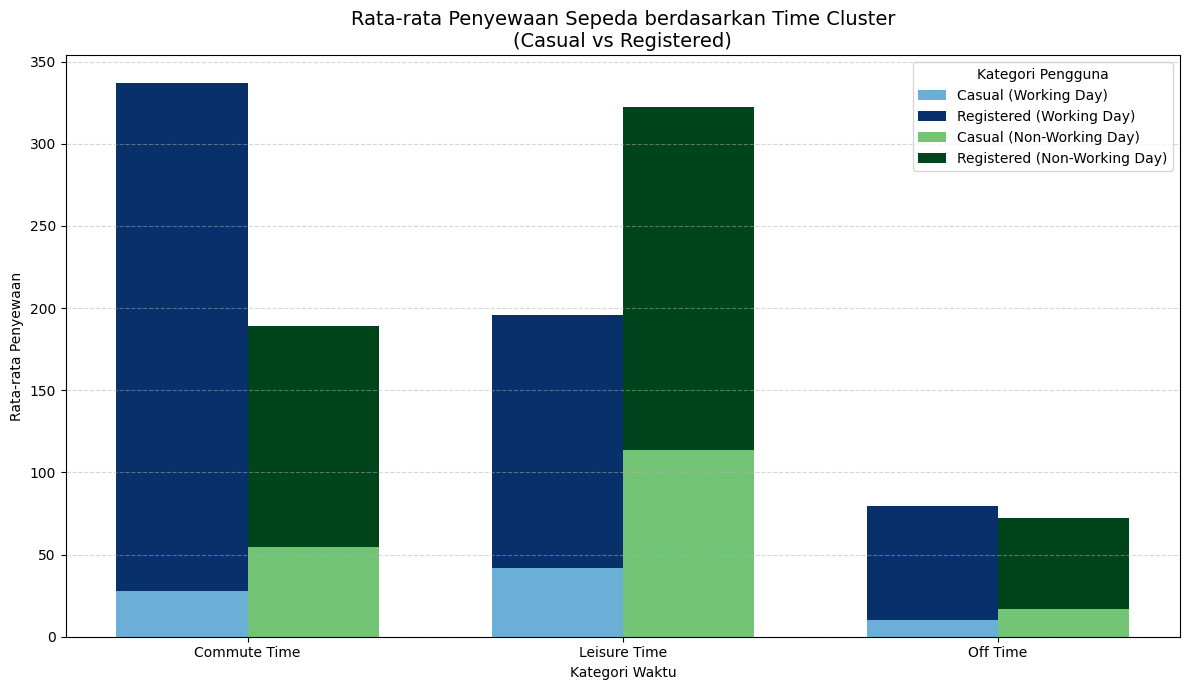

In [63]:
# Visualisasi Clustering

fig, ax = plt.subplots(figsize=(12, 7))

# Urutan label
labels = ["Commute Time", "Leisure Time", "Off Time"]
x = np.arange(len(labels))
width = 0.35

# Pisahkan working day & non-working day
wd = cluster_summary[cluster_summary["workingday"] == 1].set_index("TimeCluster").loc[labels]
nwd = cluster_summary[cluster_summary["workingday"] == 0].set_index("TimeCluster").loc[labels]

# Custom warna
colors = {
    "wd_casual": "#6BAED6",        # biru muda
    "wd_registered": "#08306B",    # biru tua
    "nwd_casual": "#74C476",       # hijau muda
    "nwd_registered": "#00441B"    # hijau tua
}

# Working Day (Stacked)

ax.bar(x - width/2,
       wd["casual"],
       width,
       color=colors["wd_casual"],
       label="Casual (Working Day)")

ax.bar(x - width/2,
       wd["registered"],
       width,
       bottom=wd["casual"],
       color=colors["wd_registered"],
       label="Registered (Working Day)")

# Non-Working Day (Stacked)

ax.bar(x + width/2,
       nwd["casual"],
       width,
       color=colors["nwd_casual"],
       label="Casual (Non-Working Day)")

ax.bar(x + width/2,
       nwd["registered"],
       width,
       bottom=nwd["casual"],
       color=colors["nwd_registered"],
       label="Registered (Non-Working Day)")

# Styling

ax.set_title("Rata-rata Penyewaan Sepeda berdasarkan Time Cluster\n(Casual vs Registered)", fontsize=14)
ax.set_xlabel("Kategori Waktu")
ax.set_ylabel("Rata-rata Penyewaan")
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.legend(title="Kategori Pengguna")
plt.tight_layout()
plt.show()

**Insight:**

* **Distribusi Data berdasarkan Time Cluster:**

  * Mayoritas observasi berada pada kategori **Off Time** (7.913 data), diikuti oleh **Leisure Time** (5.017 data) dan **Commute Time** (3.944 data).
  * Hal ini menunjukkan bahwa data lebih banyak mencakup waktu di luar jam sibuk, sehingga analisis perlu mempertimbangkan bahwa periode non-produktif memiliki proporsi terbesar dalam dataset.

* **Pola Penyewaan pada Commute Time:**

  * Pada **working day**, rata-rata penyewaan sangat tinggi (≈ 337), dengan dominasi kuat dari pengguna **registered** (≈ 309), sementara **casual** sangat kecil (≈ 28).
  * Sebaliknya pada **non-working day**, total penyewaan menurun (≈ 189) dan proporsi **casual** meningkat (≈ 54).
  * Hal ini mengindikasikan bahwa **Commute Time sangat identik dengan aktivitas rutin (pergi-pulang kerja)** yang didominasi oleh pengguna terdaftar.

* **Pola Penyewaan pada Leisure Time:**

  * Pada **non-working day**, rata-rata penyewaan mencapai nilai tertinggi (≈ 322), dengan kontribusi **casual** yang cukup besar (≈ 113).
  * Pada **working day**, jumlah penyewaan lebih rendah (≈ 195) dan didominasi oleh **registered**.
  * Ini menunjukkan bahwa **Leisure Time menjadi periode utama untuk aktivitas santai**, terutama saat akhir pekan atau hari libur.

* **Pola Penyewaan pada Off Time:**

  * Baik pada **working day** maupun **non-working day**, jumlah penyewaan relatif rendah (≈ 70–80).
  * Pengguna **registered** tetap lebih dominan dibanding casual, namun total aktivitas sangat kecil.
  * Hal ini mengindikasikan bahwa **Off Time (malam/dini hari)** bukan waktu yang optimal untuk penggunaan layanan sepeda.

* **Perbandingan Casual vs Registered:**

  * Pengguna **registered** mendominasi hampir di semua kategori waktu, terutama pada **Commute Time** dan **working day**.
  * Pengguna **casual** cenderung meningkat pada **Leisure Time** dan **non-working day**, menunjukkan pola penggunaan yang lebih fleksibel dan tidak rutin.
  * Dengan demikian, terdapat segmentasi perilaku yang jelas:

    * **Registered → utilitarian (rutinitas kerja)**
    * **Casual → recreational (waktu luang)**

## Conclusion

### **Conclusion Pertanyaan 1 (Pengaruh Faktor Lingkungan)**

Berdasarkan hasil analisis, dapat disimpulkan bahwa faktor lingkungan memang berpengaruh terhadap jumlah penyewaan sepeda, namun dengan tingkat pengaruh yang berbeda-beda.

* **Suhu (temp)** merupakan faktor yang paling dominan dengan hubungan **positif yang cukup kuat**, di mana peningkatan suhu secara konsisten diikuti oleh peningkatan jumlah penyewaan sepeda.
* **Kelembapan (hum)** memiliki hubungan **negatif yang sangat lemah**, sehingga pengaruhnya terhadap keputusan pengguna relatif tidak signifikan.
* **Kecepatan angin (windspeed)** menunjukkan hubungan **negatif**, yang mengindikasikan bahwa kondisi berangin dapat menurunkan minat pengguna, meskipun pengaruhnya tidak terlalu besar.

Secara keseluruhan, dapat disimpulkan bahwa **faktor lingkungan yang paling menentukan adalah suhu**, sehingga kondisi cuaca yang hangat menjadi pendorong utama meningkatnya penggunaan layanan bike sharing. Sementara itu, kelembapan dan kecepatan angin hanya berperan sebagai faktor tambahan yang memperkuat atau melemahkan kenyamanan pengguna.

### **Conclusion Pertanyaan 2 (Pengaruh Kondisi Cuaca)**

Analisis terhadap variasi kondisi cuaca menunjukkan adanya perbedaan pola penggunaan yang cukup signifikan.

* **Cuaca cerah** menjadi kondisi paling optimal dengan jumlah dan rata-rata penyewaan tertinggi.
* **Cuaca berawan** masih memungkinkan aktivitas penyewaan dalam jumlah cukup tinggi, meskipun mengalami penurunan dibandingkan cuaca cerah.
* **Hujan ringan** menyebabkan penurunan drastis dalam jumlah penyewaan, menunjukkan bahwa pengguna cenderung menghindari penggunaan sepeda saat kondisi cuaca buruk.

Dengan demikian, dapat disimpulkan bahwa **semakin buruk kondisi cuaca, semakin rendah tingkat penggunaan layanan bike sharing**, dan faktor hujan menjadi penghambat utama dalam aktivitas penyewaan.

### **Conclusion Analisis Lanjutan (Clustering Berdasarkan Waktu)**

Hasil clustering berdasarkan waktu memberikan insight yang lebih dalam terkait pola perilaku pengguna.

* **Commute Time (07.00–09.00 & 17.00–19.00):**

  * Menunjukkan tingkat penyewaan tertinggi pada **working day**.
  * Didominasi oleh pengguna **registered**, yang mencerminkan penggunaan untuk aktivitas rutin seperti bekerja atau sekolah.

* **Leisure Time (10.00–16.00):**

  * Menjadi periode dengan aktivitas tinggi pada **non-working day**.
  * Proporsi pengguna **casual meningkat signifikan**, menunjukkan penggunaan untuk rekreasi atau aktivitas santai.

* **Off Time (malam & dini hari):**

  * Memiliki tingkat penyewaan paling rendah baik pada working day maupun non-working day.
  * Aktivitas cenderung minimal karena keterbatasan waktu dan kondisi lingkungan.

Selain itu, terdapat pola segmentasi pengguna yang jelas:

* **Registered users** → dominan pada waktu produktif (commute & working day), bersifat rutin dan utilitarian.
* **Casual users** → dominan pada waktu luang (leisure & non-working day), bersifat fleksibel dan rekreatif.

In [64]:
requirements = """
pandas
numpy
matplotlib
seaborn
kagglehub
os
streamlit
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt berhasil dibuat!")

requirements.txt berhasil dibuat!


In [65]:
# SIMPAN SEMUA DATA

# Main data (cleaned → untuk dashboard)
main_df = hour_df.copy()

# Raw data (original → sebelum cleaning)
data_1 = raw_hour_df.copy()
data_2 = raw_day_df.copy()

# Save
main_df.to_csv("main_data.csv", index=False)
day_df.to_csv("day.csv", index=False)
data_1.to_csv("data_1.csv", index=False)
data_2.to_csv("data_2.csv", index=False)

print("Semua file berhasil disimpan!")

Semua file berhasil disimpan!
